# EEG Seizure Detection with PyTorch + CUDA

This notebook is a GPU-ready PyTorch training pipeline for the common **Epileptic Seizure Recognition** CSV dataset.

It is built for:
- CUDA training with `torch`
- binary seizure vs non-seizure classification
- strong visualizations
- threshold tuning
- model export for later use in a web app

## What this notebook does
1. Loads and cleans the EEG dataset
2. Maps labels to binary: seizure = 1, non-seizure = 0
3. Creates train / validation / test splits
4. Trains a PyTorch MLP on GPU if available
5. Tracks loss, accuracy, F1, ROC-AUC
6. Tunes the classification threshold on validation data
7. Evaluates on the test set
8. Saves the model, scaler, config, and plots

## Dataset expectation
The CSV should contain:
- one target column named `y`
- numeric EEG feature columns
- usually 178 numeric feature columns for this dataset


In [23]:
# If needed:
# !pip install torch torchvision torchaudio scikit-learn pandas matplotlib joblib


In [24]:
from pathlib import Path
import copy
import json
import math
import random
import warnings

warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
CSV_PATH = "Epileptic Seizure Recognition.csv"   # change if needed
OUTPUT_DIR = Path("torch_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")


PyTorch version: 2.10.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 5080 Laptop GPU


## 1) Load and prepare the dataset


In [25]:
def load_dataset(csv_path):
    df = pd.read_csv(csv_path)

    # Drop common index columns if present
    drop_cols = [c for c in df.columns if c in ["Unnamed", "Unnamed: 0"]]
    if drop_cols:
        df = df.drop(columns=drop_cols)

    if "y" not in df.columns:
        raise ValueError("Expected target column 'y' in dataset.")

    # Binary mapping: seizure class is 1, everything else is non-seizure
    y = df["y"].apply(lambda v: 1 if int(v) == 1 else 0).astype(np.int64)
    X = df.drop(columns=["y"])

    # Keep numeric features only
    X = X.select_dtypes(include=[np.number]).copy()

    return X, y

X_df, y_sr = load_dataset(CSV_PATH)
print("Dataset shape:", X_df.shape)
print("Positive rate:", round(float(y_sr.mean()), 4))
display(y_sr.value_counts().rename(index={0: "non-seizure", 1: "seizure"}).to_frame("count"))


Dataset shape: (11500, 178)
Positive rate: 0.2


,count
y,
non-seizure,9200
seizure,2300


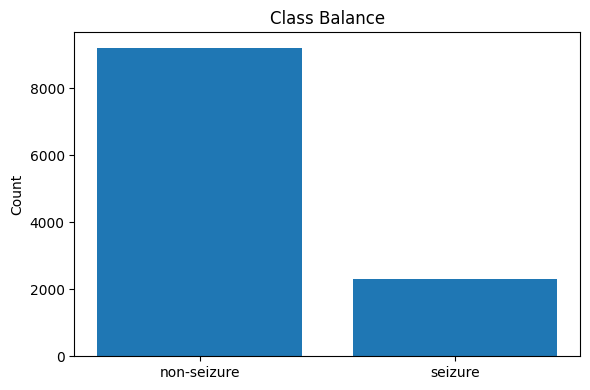

In [26]:
plt.figure(figsize=(6, 4))
counts = y_sr.value_counts().sort_index()
plt.bar(["non-seizure", "seizure"], counts.values)
plt.title("Class Balance")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("torch_outputs/class_distribution.png")
plt.show()


## 2) Train / validation / test split

We keep a dedicated test set untouched until the end.
The validation split is used for early stopping and threshold tuning.


In [27]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_df, y_sr,
    test_size=0.15,
    stratify=y_sr,
    random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.1765,  # about 15% overall validation after first split
    stratify=y_trainval,
    random_state=SEED
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (8049, 178)
Val shape: (1726, 178)
Test shape: (1725, 178)


## 3) Imputation + scaling

For a neural network on tabular data, standardization is important.
We fit preprocessing on the training split only.


In [28]:
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_imp).astype(np.float32)
X_val_scaled = scaler.transform(X_val_imp).astype(np.float32)
X_test_scaled = scaler.transform(X_test_imp).astype(np.float32)

y_train_np = y_train.to_numpy(dtype=np.float32)
y_val_np = y_val.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)

print("Processed train shape:", X_train_scaled.shape)


Processed train shape: (8049, 178)


## 4) PyTorch dataset and dataloaders


In [29]:
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 256

train_ds = EEGDataset(X_train_scaled, y_train_np)
val_ds = EEGDataset(X_val_scaled, y_val_np)
test_ds = EEGDataset(X_test_scaled, y_test_np)

pin_memory = torch.cuda.is_available()

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_memory)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_memory)

input_dim = X_train_scaled.shape[1]
print("Input dim:", input_dim)


Input dim: 178


## 5) Define the model

This is a strong tabular MLP baseline with:
- BatchNorm
- ReLU
- Dropout
- residual-style depth through multiple hidden layers


In [30]:
class SeizureMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=(256, 128, 64), dropout=0.25):
        super().__init__()

        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev = h

        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(prev, 1)

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x).squeeze(1)
        return x

model = SeizureMLP(input_dim=input_dim).to(device)
print(model)


SeizureMLP(
  (backbone): Sequential(
    (0): Linear(in_features=178, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.25, inplace=False)
  )
  (head): Linear(in_features=64, out_features=1, bias=True)
)


## 6) Training utilities

We use:
- `BCEWithLogitsLoss`
- class weighting for imbalance
- AdamW
- mixed precision on CUDA
- early stopping on validation ROC-AUC


In [31]:
pos_count = y_train_np.sum()
neg_count = len(y_train_np) - pos_count
pos_weight = torch.tensor([neg_count / max(pos_count, 1.0)], dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

use_amp = torch.cuda.is_available()
scaler_amp = torch.amp.GradScaler("cuda", enabled=use_amp)

EPOCHS = 35
EARLY_STOPPING_PATIENCE = 8


In [32]:
def sigmoid_np(x):
    return 1 / (1 + np.exp(-x))

@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_logits = []
    all_targets = []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = model(xb)
        all_logits.append(logits.detach().cpu().numpy())
        all_targets.append(yb.detach().cpu().numpy())

    logits = np.concatenate(all_logits)
    targets = np.concatenate(all_targets)
    probs = sigmoid_np(logits)
    return targets, probs

def evaluate_probs(y_true, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, preds),
        "balanced_accuracy": balanced_accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probs),
    }

def find_best_threshold(y_true, probs):
    thresholds = np.linspace(0.10, 0.90, 81)
    rows = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        rows.append({
            "threshold": t,
            "f1": f1_score(y_true, preds, zero_division=0),
            "precision": precision_score(y_true, preds, zero_division=0),
            "recall": recall_score(y_true, preds, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_true, preds),
        })
    df = pd.DataFrame(rows).sort_values(["f1", "balanced_accuracy", "recall"], ascending=False).reset_index(drop=True)
    return df, float(df.iloc[0]["threshold"])


In [33]:
history = []
best_state = None
best_val_auc = -np.inf
best_epoch = -1
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_count = 0

    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(xb)
            loss = criterion(logits, yb)

        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()

        bs = xb.size(0)
        running_loss += loss.item() * bs
        running_count += bs

    train_loss = running_loss / running_count

    y_train_true, train_probs = predict_loader(model, train_loader)
    y_val_true, val_probs = predict_loader(model, val_loader)

    train_metrics = evaluate_probs(y_train_true, train_probs, threshold=0.5)
    val_metrics = evaluate_probs(y_val_true, val_probs, threshold=0.5)

    scheduler.step(val_metrics["roc_auc"])

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "train_roc_auc": train_metrics["roc_auc"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"],
        "val_roc_auc": val_metrics["roc_auc"],
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"loss={train_loss:.4f} | "
        f"train_auc={train_metrics['roc_auc']:.4f} | "
        f"val_auc={val_metrics['roc_auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["roc_auc"] > best_val_auc:
        best_val_auc = val_metrics["roc_auc"]
        best_epoch = epoch
        patience_counter = 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

history_df = pd.DataFrame(history)
history_df


Epoch 01 | loss=0.5303 | train_auc=0.9935 | val_auc=0.9889 | val_f1=0.8997
Epoch 02 | loss=0.3431 | train_auc=0.9958 | val_auc=0.9909 | val_f1=0.9104
Epoch 03 | loss=0.2536 | train_auc=0.9970 | val_auc=0.9920 | val_f1=0.9213
Epoch 04 | loss=0.1971 | train_auc=0.9977 | val_auc=0.9930 | val_f1=0.9203
Epoch 05 | loss=0.1570 | train_auc=0.9983 | val_auc=0.9931 | val_f1=0.9279
Epoch 06 | loss=0.1344 | train_auc=0.9986 | val_auc=0.9933 | val_f1=0.9250
Epoch 07 | loss=0.1173 | train_auc=0.9990 | val_auc=0.9931 | val_f1=0.9252
Epoch 08 | loss=0.1097 | train_auc=0.9991 | val_auc=0.9934 | val_f1=0.9239
Epoch 09 | loss=0.0996 | train_auc=0.9992 | val_auc=0.9932 | val_f1=0.9268
Epoch 10 | loss=0.0917 | train_auc=0.9993 | val_auc=0.9931 | val_f1=0.9318
Epoch 11 | loss=0.0807 | train_auc=0.9994 | val_auc=0.9944 | val_f1=0.9272
Epoch 12 | loss=0.0723 | train_auc=0.9995 | val_auc=0.9942 | val_f1=0.9313
Epoch 13 | loss=0.0730 | train_auc=0.9996 | val_auc=0.9946 | val_f1=0.9347
Epoch 14 | loss=0.0685 | 

,epoch,train_loss,train_accuracy,train_f1,train_roc_auc,val_accuracy,val_f1,val_roc_auc,lr
0,1,0.530339,0.967698,0.923394,0.993466,0.957126,0.899729,0.988907,0.001000
1,2,0.343125,0.976892,0.944010,0.995767,0.962920,0.910364,0.990859,0.001000
2,3,0.253623,0.980743,0.953355,0.996982,0.967555,0.921348,0.991999,0.001000
3,4,0.197073,0.982234,0.956915,0.997670,0.966976,0.920280,0.993013,0.001000
4,5,0.157027,0.984967,0.963411,0.998261,0.970452,0.927864,0.993084,0.001000
5,6,0.134446,0.986085,0.966019,0.998619,0.969293,0.925035,0.993294,0.001000
6,7,0.117261,0.987203,0.968645,0.999024,0.969293,0.925247,0.993107,0.001000
7,8,0.109714,0.986955,0.968153,0.999120,0.968714,0.923944,0.993357,0.001000
8,9,0.099585,0.988818,0.972494,0.999199,0.969873,0.926761,0.993170,0.001000
9,10,0.091672,0.990309,0.976176,0.999318,0.972190,0.931818,0.993126,0.000500


In [34]:
if best_state is not None:
    model.load_state_dict(best_state)

print("Best validation ROC-AUC:", round(best_val_auc, 6))
print("Best epoch:", best_epoch)


Best validation ROC-AUC: 0.994652
Best epoch: 15


## 7) Training curves


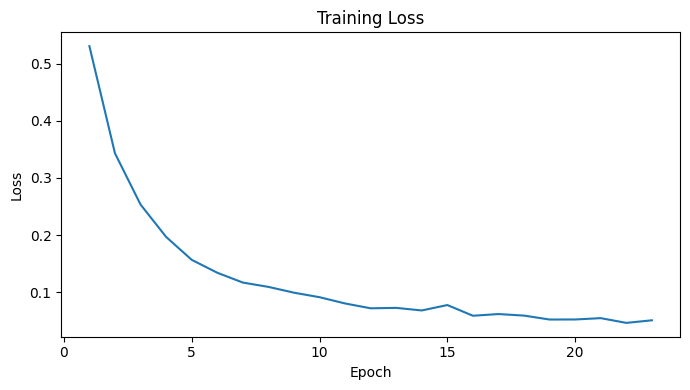

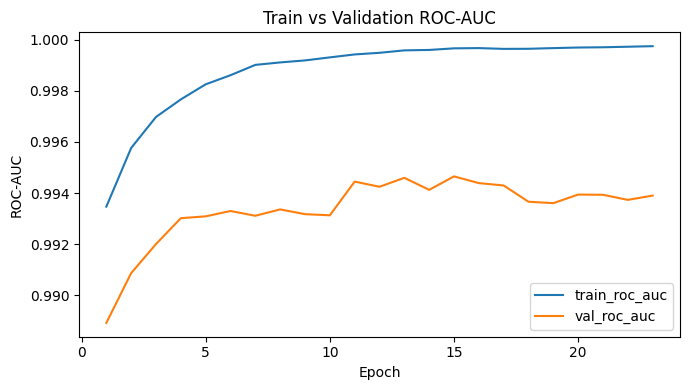

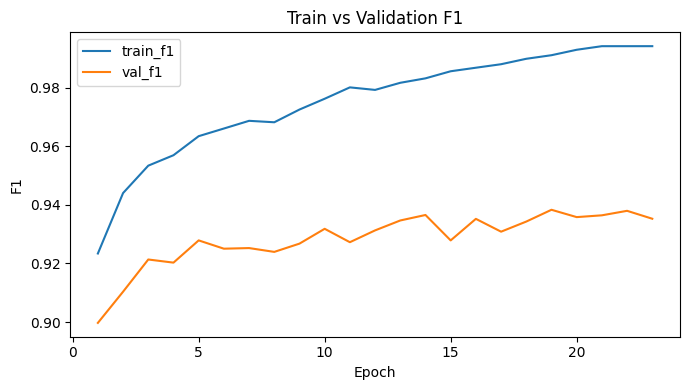

In [35]:
plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.tight_layout()
plt.savefig("torch_outputs/loss_per_epoch.png")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_roc_auc"], label="train_roc_auc")
plt.plot(history_df["epoch"], history_df["val_roc_auc"], label="val_roc_auc")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Train vs Validation ROC-AUC")
plt.legend()
plt.tight_layout()
plt.savefig("torch_outputs/train_vs_val_roc.png")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_f1"], label="train_f1")
plt.plot(history_df["epoch"], history_df["val_f1"], label="val_f1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Train vs Validation F1")
plt.legend()
plt.tight_layout()
plt.savefig("torch_outputs/train_vs_val.png")
plt.show()


## 8) Tune threshold on validation set

The default threshold is 0.5, but seizure tasks often benefit from threshold tuning.


In [36]:
y_val_true, val_probs = predict_loader(model, val_loader)
threshold_table, best_threshold = find_best_threshold(y_val_true, val_probs)
df = threshold_table.sort_values("threshold")
print("Best validation threshold:", round(best_threshold, 4))
display(threshold_table.head(10))


Best validation threshold: 0.63


,threshold,f1,precision,recall,balanced_accuracy
0,0.63,0.933526,0.930836,0.936232,0.959427
1,0.56,0.932568,0.923295,0.942029,0.961239
2,0.85,0.932331,0.968750,0.898551,0.945655
3,0.64,0.931785,0.933140,0.930435,0.956890
4,0.54,0.931624,0.915966,0.947826,0.963051
5,0.68,0.931387,0.938235,0.924638,0.954716
6,0.69,0.931387,0.938235,0.924638,0.954716
7,0.81,0.931343,0.960000,0.904348,0.947467
8,0.55,0.931232,0.920680,0.942029,0.960877
9,0.57,0.931034,0.923077,0.939130,0.959790


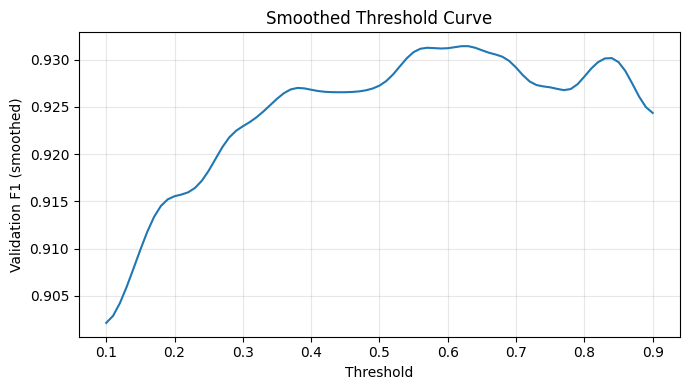

In [37]:
from scipy.ndimage import gaussian_filter1d

smoothed = gaussian_filter1d(df["f1"], sigma=2)

plt.figure(figsize=(7, 4))
plt.plot(df["threshold"], smoothed)
plt.xlabel("Threshold")
plt.ylabel("Validation F1 (smoothed)")
plt.title("Smoothed Threshold Curve")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("torch_outputs/smoothed_threshold_curve.png")
plt.show()

## 9) Final test evaluation


In [38]:
y_test_true, test_probs = predict_loader(model, test_loader)

test_metrics_05 = evaluate_probs(y_test_true, test_probs, threshold=0.5)
test_metrics_best = evaluate_probs(y_test_true, test_probs, threshold=best_threshold)

print("Test metrics @ threshold=0.5")
for k, v in test_metrics_05.items():
    print(f"{k}: {v:.6f}")

print("\nTest metrics @ tuned threshold")
for k, v in test_metrics_best.items():
    print(f"{k}: {v:.6f}")


Test metrics @ threshold=0.5
accuracy: 0.977971
balanced_accuracy: 0.965580
precision: 0.944928
recall: 0.944928
f1: 0.944928
roc_auc: 0.997276

Test metrics @ tuned threshold
accuracy: 0.979710
balanced_accuracy: 0.963406
precision: 0.961310
recall: 0.936232
f1: 0.948605
roc_auc: 0.997276


In [39]:
test_preds_best = (test_probs >= best_threshold).astype(int)
print(classification_report(y_test_true, test_preds_best, digits=4))


              precision    recall  f1-score   support

         0.0     0.9842    0.9906    0.9874      1380
         1.0     0.9613    0.9362    0.9486       345

    accuracy                         0.9797      1725
   macro avg     0.9727    0.9634    0.9680      1725
weighted avg     0.9796    0.9797    0.9796      1725



## 10) Confusion matrix, ROC curve, PR curve


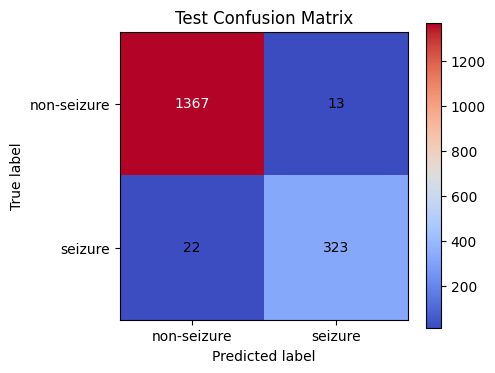

In [40]:
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test_true, test_preds_best)


plt.figure(figsize=(5, 4))

# Change colormap here 👇
plt.imshow(cm, cmap="coolwarm")  # try: 'viridis', 'plasma', 'inferno', 'Blues', 'coolwarm'

plt.title("Test Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["non-seizure", "seizure"])
plt.yticks([0, 1], ["non-seizure", "seizure"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig("torch_outputs/confusion_matrix.png")
plt.show()

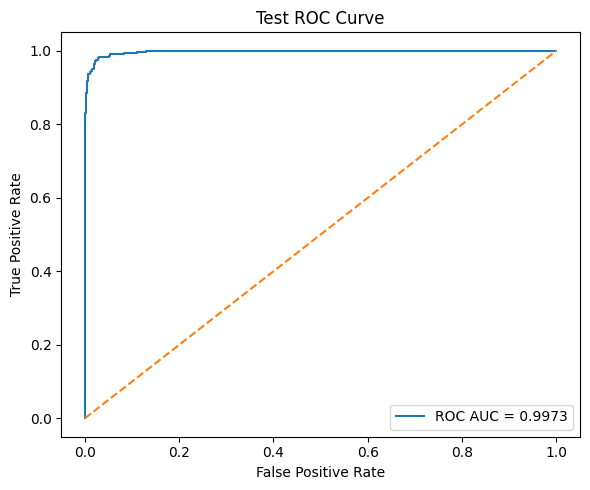

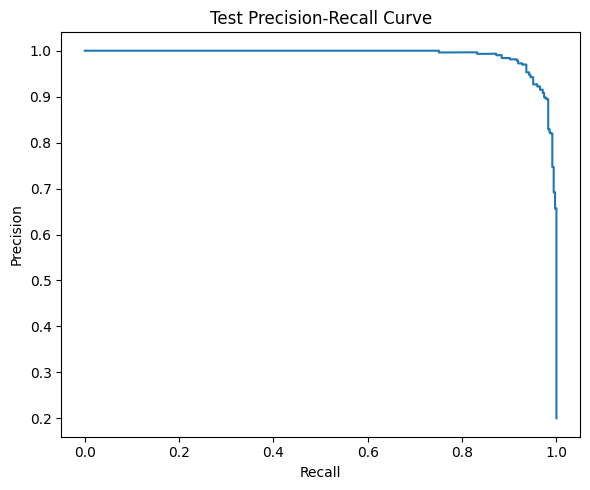

In [41]:
fpr, tpr, _ = roc_curve(y_test_true, test_probs)
roc_auc = roc_auc_score(y_test_true, test_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("torch_outputs/test_roc.png")
plt.show()

precision, recall, _ = precision_recall_curve(y_test_true, test_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test Precision-Recall Curve")
plt.tight_layout()
plt.savefig("torch_outputs/test_precision_recall.png")
plt.show()


## 11) Inspect a few predicted probabilities


In [42]:
pred_df = pd.DataFrame({
    "true_label": y_test_true.astype(int),
    "pred_probability": test_probs,
    "pred_label": (test_probs >= best_threshold).astype(int)
})
pred_df.head(20)


,true_label,pred_probability,pred_label
0,0,0.006016,0
1,0,0.004267,0
2,0,0.004989,0
3,1,0.988856,1
4,0,0.008527,0
5,1,1.000000,1
6,0,0.030498,0
7,0,0.008273,0
8,0,0.040257,0
9,0,0.005695,0


## 12) Save artifacts for your future app

This saves:
- the trained PyTorch model weights
- preprocessing objects
- threshold
- config
- training history


In [43]:
model_path = OUTPUT_DIR / "seizure_mlp_state_dict.pt"
preprocess_path = OUTPUT_DIR / "preprocessing.joblib"
config_path = OUTPUT_DIR / "config.json"
history_path = OUTPUT_DIR / "history.csv"
preds_path = OUTPUT_DIR / "test_predictions.csv"

torch.save(model.state_dict(), model_path)
joblib.dump({
    "imputer": imputer,
    "scaler": scaler,
    "feature_names": X_df.columns.tolist(),
}, preprocess_path)

config = {
    "input_dim": int(input_dim),
    "hidden_dims": [256, 128, 64],
    "dropout": 0.25,
    "best_threshold": float(best_threshold),
    "seed": SEED,
    "csv_path": CSV_PATH,
}
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

history_df.to_csv(history_path, index=False)
pred_df.to_csv(preds_path, index=False)

print("Saved:")
print("-", model_path)
print("-", preprocess_path)
print("-", config_path)
print("-", history_path)
print("-", preds_path)


Saved:
- torch_outputs\seizure_mlp_state_dict.pt
- torch_outputs\preprocessing.joblib
- torch_outputs\config.json
- torch_outputs\history.csv
- torch_outputs\test_predictions.csv


## 13) Load the model later for inference

Use this when you want to integrate the model into your React-backed app or an API.


In [44]:
# Example reload code

reloaded_model = SeizureMLP(input_dim=config["input_dim"], hidden_dims=tuple(config["hidden_dims"]), dropout=config["dropout"])
reloaded_model.load_state_dict(torch.load(model_path, map_location=device))
reloaded_model.to(device)
reloaded_model.eval()

bundle = joblib.load(preprocess_path)
loaded_imputer = bundle["imputer"]
loaded_scaler = bundle["scaler"]
loaded_feature_names = bundle["feature_names"]

print("Reloaded successfully.")


Reloaded successfully.


## 14) Next upgrades you can add

Good next steps for even better performance:
- K-fold training with model ensembling
- focal loss
- 1D CNN on ordered EEG feature vectors
- Optuna hyperparameter search
- SHAP or integrated gradients style explanations
- subject-aware splitting if you move to patient-level data

For the web app later:
- `/` can host simulations and live predictions
- `/research` can show training curves, ROC/PR, confusion matrix, threshold sweep, and model notes
